# Chapter 7 — Coordination: The Asymmetric Model
**Modeling Social Behavior** | Smaldino

---

## 📚 How This Model Differs From the Simple Model

In the **simple coordination model**, the two norms were perfectly symmetric, neither was intrinsically better. Whatever was more common would win, and the outcome was purely determined by initial frequency and random drift.

In the **asymmetric coordination model**, the two norms are *not* equal:

- **Norm 1** is **prosocially better** — when everyone uses it, it produces a higher collective payoff than Norm 2.
- **But Norm 1 is costlier when rare** — if you hold Norm 1 in a population where most people use Norm 2, you pay a rarity cost (you fail to coordinate with the majority).

This is based on the **stag hunt** logic from game theory, extended by Boyd & Richerson (2002). It models norms like:
- Recycling (good for everyone, but annoying to do alone)
- Speaking a minority language
- Adopting a superior but unpopular technology standard
- Prosocial behaviors that require coordination to pay off

---

## 🧮 The Payoff Structure (Read This Carefully)

Agents interact with the whole population (mean-field). Each interaction has one of four outcomes:

| Focal agent | Partner agent | Outcome |
|---|---|---|
| Norm 1 | Norm 1 | Coordination! Focal gets `1 + prosocial_benefit + coord_benefit` |
| Norm 1 | Norm 2 | Mismatch. Focal pays rarity cost; gets `1 - rarity_cost` |
| Norm 2 | Norm 1 | Partial benefit: gets `1 + prosocial_benefit` (Norm 1 partner is prosocial) |
| Norm 2 | Norm 2 | No coordination benefit, no cost: gets `1` |

**Expected payoffs** (averaged over all possible partners, weighted by their frequency):

$$\pi_1 = p_1 \cdot (1 + b_p + b_c) + (1 - p_1) \cdot (1 - c_r)$$

$$\pi_2 = p_1 \cdot (1 + b_p) + (1 - p_1) \cdot 1$$

Where:
- $p_1$ = frequency of Norm 1 in the population
- $b_p$ = `norm1_prosocial_benefit` — the benefit Norm 2 agents get when interacting with a Norm 1 agent (Norm 1 is prosocial even toward non-adopters)
- $b_c$ = `norm1_coord_benefit` — the *extra* benefit Norm 1 agents get when they successfully coordinate with another Norm 1 agent
- $c_r$ = `norm1_rarity_cost` — the cost Norm 1 agents pay when they fail to coordinate (interacting with a Norm 2 agent)

---

## 📐 The Critical Threshold p*

The most important mathematical insight in this model is that there exists a **tipping point** $p^*$ — a critical frequency of Norm 1 above which Norm 1 will inevitably spread, and below which Norm 1 will go extinct.

We find $p^*$ by setting $\pi_1 = \pi_2$ and solving for $p_1$:

$$p_1(1 + b_p + b_c) + (1-p_1)(1 - c_r) = p_1(1 + b_p) + (1-p_1)(1)$$

After algebra:

$$\boxed{p^* = \frac{c_r}{c_r + b_c}}$$

**Key observations:**
- The prosocial benefit $b_p$ cancels out! It doesn't affect $p^*$ — it shifts both payoffs equally.
- $p^*$ is determined only by the ratio of rarity cost to coordination benefit.
- If $p_1 > p^*$ → Norm 1 is favored → Norm 1 spreads toward fixation.
- If $p_1 < p^*$ → Norm 2 is favored → Norm 1 disappears.
- If $p^* > 0.5$ → even a majority of Norm 1 holders can't guarantee it wins (high rarity cost).
- If $p^* < 0.5$ → Norm 1 can spread even from a minority position.

This is an **unstable equilibrium** — not a stable one. The population won't rest at $p^*$; it will tip away from it in one direction or the other.

---

## 🔄 Imitation Rule Change (Important!)

In the simple model, agents **only considered copying someone with a different norm**. Here, agents compare payoffs with **any random other agent** — even one with the same norm. If the other has the same norm, copying still happens (it just doesn't change anything). This is a slightly different, arguably more realistic implementation of the Fermi rule, but functionally produces the same directional dynamics.

---

## 🔢 Variable Reference

| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_norm1` | Global (parameter) | Initial fraction of agents with Norm 1 |
| `norm1_prosocial_benefit` | Global (parameter) | Benefit Norm 2 agents get when paired with Norm 1 ($b_p$) |
| `norm1_coord_benefit` | Global (parameter) | Extra bonus when two Norm 1 agents meet ($b_c$) |
| `norm1_rarity_cost` | Global (parameter) | Cost Norm 1 agents pay when paired with Norm 2 ($c_r$) |
| `agent.norm` | Agent | Integer: 1 = Norm 1, 2 = Norm 2 |
| `agent.payoff` | Agent | Float: agent's current expected payoff |
| `p1` | Local | Frequency of Norm 1 this tick |
| `p_star` | Local/Global | Tipping point: $c_r / (c_r + b_c)$ |
| `history` | Global | List tracking freq of Norm 1 over time |

---

## 📦 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import random

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## 🤖 Agent Class

In [2]:
class Agent:
    """
    Represents one individual in the asymmetric coordination model.

    Agent-level attributes:
    -----------------------
    norm   : int   — which norm the agent holds (1 or 2)
    payoff : float — the agent's expected payoff this tick
    """

    def __init__(self, norm):
        self.norm   = norm   # int: 1 or 2
        self.payoff = 0.0    # float: set each tick by calculate_payoffs()

---
## ⚙️ Model Functions

In [3]:
def setup(N, init_norm1):
    """
    Create the population and randomly assign norms.

    Global parameters used:
    -----------------------
    N          : int   — total number of agents
    init_norm1 : float — probability any agent starts with Norm 1

    Returns:
    --------
    agents : list of Agent
    """
    agents = []
    for _ in range(N):
        norm = 1 if random.random() < init_norm1 else 2
        agents.append(Agent(norm))
    return agents


def calculate_payoffs(agents, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost):
    """
    Compute expected payoffs for all agents based on current norm frequencies.

    Payoffs assume mean-field interactions (each agent effectively interacts
    with the entire population, weighted by norm frequencies).

    Payoff formulas:
        π₁ = p1*(1 + bp + bc) + (1 - p1)*(1 - cr)
        π₂ = p1*(1 + bp)      + (1 - p1)*1

    Parameters (all global-level parameters passed in):
    ---------------------------------------------------
    agents                 : list of Agent
    norm1_prosocial_benefit: float — bp: benefit even Norm 2 agents get from Norm 1 partners
    norm1_coord_benefit    : float — bc: extra benefit when two Norm 1 agents meet
    norm1_rarity_cost      : float — cr: cost Norm 1 pays when meeting a Norm 2 partner

    Modifies agents in place.
    """

    N  = len(agents)  # local

    # Local: frequency of Norm 1 this tick
    p1 = sum(1 for a in agents if a.norm == 1) / N

    # Local: expected payoff for each norm group
    # Norm 1: gets coordination bonus bc when meeting another Norm 1,
    #         but pays rarity cost cr when meeting a Norm 2
    norm1_payoff = (p1 * (1 + norm1_prosocial_benefit + norm1_coord_benefit)
                  + (1 - p1) * (1 - norm1_rarity_cost))

    # Norm 2: gets the prosocial spillover bp when meeting a Norm 1 agent,
    #         gets baseline 1 when meeting another Norm 2
    norm2_payoff = (p1 * (1 + norm1_prosocial_benefit)
                  + (1 - p1) * 1)

    # Assign payoffs
    for agent in agents:
        agent.payoff = norm1_payoff if agent.norm == 1 else norm2_payoff


def fermi(payoff_other, payoff_self):
    """
    Logistic function: probability of copying the other agent's norm.

    P(copy) = 1 / (1 + exp(-(payoff_other - payoff_self)))

    Same as in the simple model. Returns a float in (0, 1).
    """
    return 1.0 / (1.0 + np.exp(-(payoff_other - payoff_self)))


def evolve(agents):
    """
    One full round of success-biased imitation.

    KEY DIFFERENCE FROM SIMPLE MODEL:
    In the simple model, agents only looked at someone with a *different* norm.
    Here, agents pick ANY random other agent (same or different norm).
    If both have the same norm, the copy operation changes nothing —
    but the Fermi rule still applies. This is a slightly more general
    implementation of the same logic.

    Parameters:
    -----------
    agents : list of Agent

    Modifies agents in place.
    """

    shuffled = agents[:]          # local: copy of list to shuffle update order
    random.shuffle(shuffled)

    for agent in shuffled:
        # Pick any random other agent as the model (including same-norm agents)
        model = random.choice(agents)  # local

        # Local: probability of copying based on payoff difference
        prob_copy = fermi(model.payoff, agent.payoff)

        # With prob_copy, adopt the model's norm
        # (If model has same norm, this is a no-op)
        if random.random() < prob_copy:
            agent.norm = model.norm


def p_star(norm1_rarity_cost, norm1_coord_benefit):
    """
    Compute the analytical tipping point p*.

    Above p*: Norm 1 has higher expected payoff → spreads.
    Below p*: Norm 2 has higher expected payoff → Norm 1 shrinks.

    Formula: p* = cr / (cr + bc)

    Note: the prosocial benefit bp does NOT appear here —
    it cancels out when you set π₁ = π₂.

    Parameters:
    -----------
    norm1_rarity_cost   : float — cr
    norm1_coord_benefit : float — bc

    Returns:
    --------
    float — the critical tipping frequency
    """
    return norm1_rarity_cost / (norm1_rarity_cost + norm1_coord_benefit)


def run(N, init_norm1, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost, max_ticks=3000):
    """
    Run the full asymmetric coordination simulation.

    Global parameters:
    ------------------
    N                       : int   — population size
    init_norm1              : float — initial frequency of Norm 1
    norm1_prosocial_benefit : float — bp
    norm1_coord_benefit     : float — bc
    norm1_rarity_cost       : float — cr
    max_ticks               : int   — maximum simulation length

    Returns:
    --------
    history : list of float — frequency of Norm 1 at each tick
    """

    agents  = setup(N, init_norm1)
    history = []

    for tick in range(max_ticks):

        # Count Norm 1 holders this tick
        n_norm1 = sum(1 for a in agents if a.norm == 1)  # local
        history.append(n_norm1 / N)

        # Stop if one norm has fixed (taken over completely)
        if n_norm1 == 0 or n_norm1 == N:
            break

        calculate_payoffs(agents, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost)
        evolve(agents)

    return history

---
## 🔬 Experiment 0: Visualize the Payoff Functions

Before running the simulation, let's visualize the payoff functions analytically.

This is the key insight of the asymmetric model: depending on the current frequency $p_1$, either Norm 1 or Norm 2 yields a higher payoff. The crossover point is exactly $p^*$.

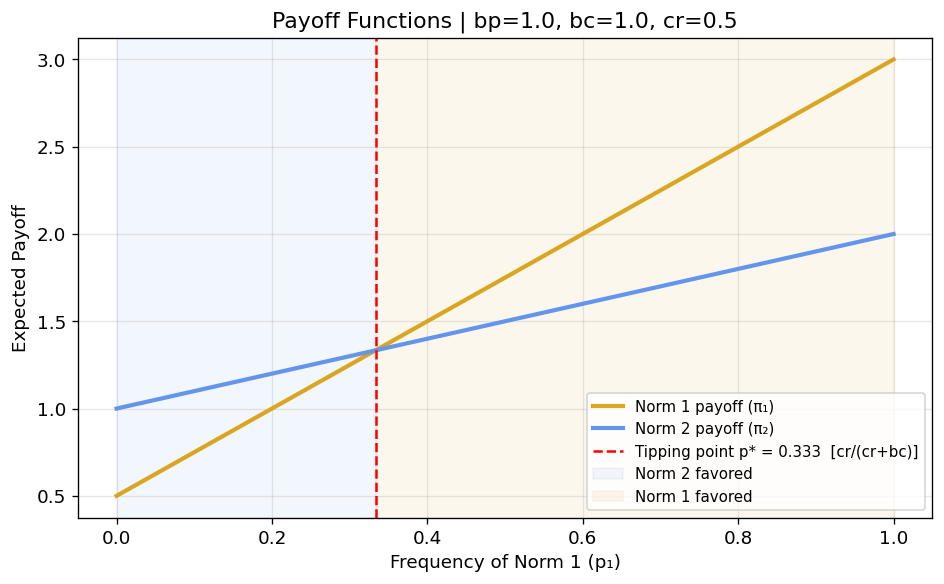

Analytical tipping point p* = 0.3333
  → Norm 1 must exceed 33.3% of the population to be favored by selection.
  Note: prosocial benefit bp=1.0 does NOT affect p* — it shifts both curves equally.


In [4]:
# ── Global parameters ──────────────────────────────────────────────────────────
norm1_prosocial_benefit = 1.0   # bp
norm1_coord_benefit     = 1.0   # bc
norm1_rarity_cost       = 0.5   # cr
# ───────────────────────────────────────────────────────────────────────────────

# Local: sweep p1 from 0 to 1
p1_values = np.linspace(0, 1, 200)

# Compute both payoffs analytically across all p1 values
pi1 = p1_values * (1 + norm1_prosocial_benefit + norm1_coord_benefit) + (1 - p1_values) * (1 - norm1_rarity_cost)
pi2 = p1_values * (1 + norm1_prosocial_benefit) + (1 - p1_values) * 1

# Compute the analytical tipping point
pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p1_values, pi1, color='goldenrod',      linewidth=2.5, label='Norm 1 payoff (π₁)')
ax.plot(p1_values, pi2, color='cornflowerblue', linewidth=2.5, label='Norm 2 payoff (π₂)')

# Mark the tipping point where π₁ = π₂
ax.axvline(pstar, color='red', linestyle='--', linewidth=1.5,
           label=f'Tipping point p* = {pstar:.3f}  [cr/(cr+bc)]')

# Shade regions: left of p* → Norm 2 favored; right of p* → Norm 1 favored
ax.axvspan(0,     pstar, alpha=0.08, color='cornflowerblue', label='Norm 2 favored')
ax.axvspan(pstar, 1,     alpha=0.08, color='goldenrod',      label='Norm 1 favored')

ax.set_xlabel('Frequency of Norm 1 (p₁)')
ax.set_ylabel('Expected Payoff')
ax.set_title(f'Payoff Functions | bp={norm1_prosocial_benefit}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analytical tipping point p* = {pstar:.4f}")
print(f"  → Norm 1 must exceed {pstar*100:.1f}% of the population to be favored by selection.")
print(f"  Note: prosocial benefit bp={norm1_prosocial_benefit} does NOT affect p* — it shifts both curves equally.")

---
## 🔬 Experiment 1: Single Run — Tipping in Action

Run the model once with an initial frequency above and below $p^*$ to confirm the tipping behavior.

p* = 0.333


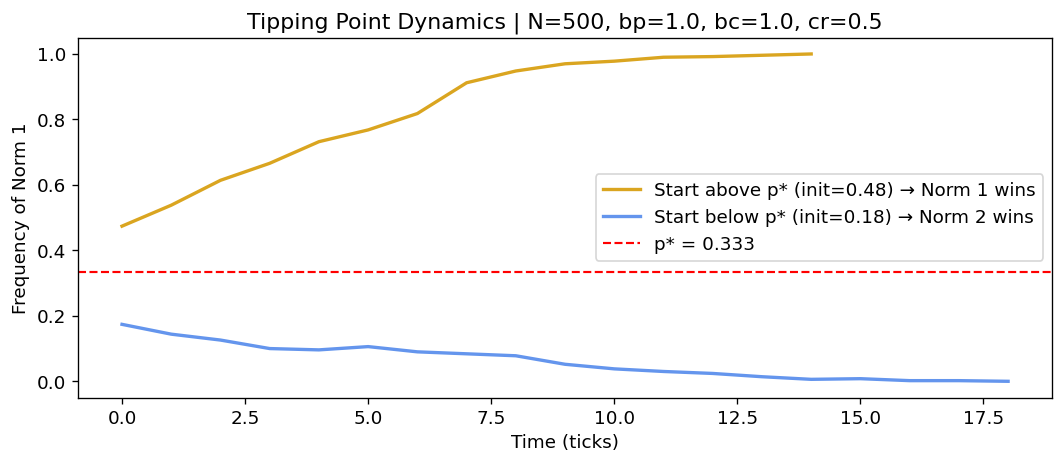

In [5]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 500
norm1_prosocial_benefit = 1.0   # bp
norm1_coord_benefit     = 1.0   # bc
norm1_rarity_cost       = 0.5   # cr
max_ticks               = 2000
# ───────────────────────────────────────────────────────────────────────────────

# Compute tipping point analytically
pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)
print(f"p* = {pstar:.3f}")

# Run once above p* and once below p*
random.seed(1)
h_above = run(N, init_norm1=pstar + 0.15,   # well above the tipping point
              norm1_prosocial_benefit=norm1_prosocial_benefit,
              norm1_coord_benefit=norm1_coord_benefit,
              norm1_rarity_cost=norm1_rarity_cost,
              max_ticks=max_ticks)

random.seed(2)
h_below = run(N, init_norm1=pstar - 0.15,   # well below the tipping point
              norm1_prosocial_benefit=norm1_prosocial_benefit,
              norm1_coord_benefit=norm1_coord_benefit,
              norm1_rarity_cost=norm1_rarity_cost,
              max_ticks=max_ticks)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(h_above, color='goldenrod',      linewidth=2, label=f'Start above p* (init={pstar+0.15:.2f}) → Norm 1 wins')
ax.plot(h_below, color='cornflowerblue', linewidth=2, label=f'Start below p* (init={pstar-0.15:.2f}) → Norm 2 wins')
ax.axhline(pstar, color='red', linestyle='--', linewidth=1.3, label=f'p* = {pstar:.3f}')

ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1')
ax.set_title(f'Tipping Point Dynamics | N={N}, bp={norm1_prosocial_benefit}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}')
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 2: Multiple Runs — Stochasticity Near p*

Starting exactly at $p^*$ is the most interesting case: the deterministic prediction says it's a neutral point, but stochasticity means individual runs will tip one way or the other.

Starting just above $p^*$ should produce mostly Norm 1 wins; just below should produce mostly Norm 2 wins — but neither is guaranteed.

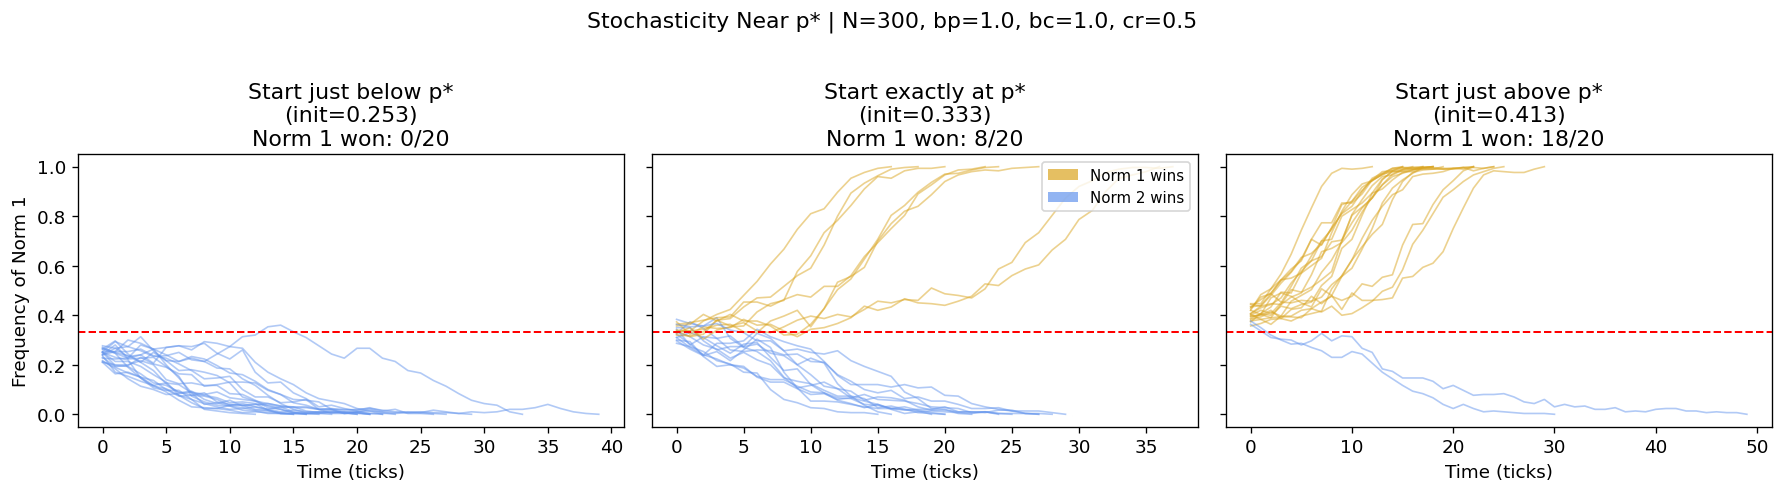

In [6]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 300
norm1_prosocial_benefit = 1.0
norm1_coord_benefit     = 1.0
norm1_rarity_cost       = 0.5
max_ticks               = 3000
n_runs                  = 20
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

# Three starting conditions: just below, at, and just above p*
start_conditions = [
    (pstar - 0.08, 'Start just below p*'),
    (pstar,        'Start exactly at p*'),
    (pstar + 0.08, 'Start just above p*'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (init_val, title) in zip(axes, start_conditions):
    wins_norm1 = 0  # local counter

    for _ in range(n_runs):
        h = run(N, init_val, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost, max_ticks)
        won = h[-1] == 1.0
        if won:
            wins_norm1 += 1
        color = 'goldenrod' if won else 'cornflowerblue'
        ax.plot(h, color=color, alpha=0.5, linewidth=1)

    ax.axhline(pstar, color='red', linestyle='--', linewidth=1.2, label=f'p* = {pstar:.2f}')
    ax.set_title(f'{title}\n(init={init_val:.3f})\nNorm 1 won: {wins_norm1}/{n_runs}')
    ax.set_xlabel('Time (ticks)')
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('Frequency of Norm 1')

legend_elements = [
    Patch(facecolor='goldenrod',      alpha=0.7, label='Norm 1 wins'),
    Patch(facecolor='cornflowerblue', alpha=0.7, label='Norm 2 wins'),
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

fig.suptitle(f'Stochasticity Near p* | N={N}, bp={norm1_prosocial_benefit}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}',
             y=1.02)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 3: Win Probability Curve — Asymmetry vs. Simple Model

In the simple model, the win probability curve was centered at 0.5.

In the asymmetric model, it should be **centered at p*** instead. This is the signature of asymmetry: the threshold for Norm 1 to reliably win is shifted away from 50%.

In [7]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 200
norm1_prosocial_benefit = 1.0
norm1_coord_benefit     = 1.0
norm1_rarity_cost       = 0.5
max_ticks               = 5000
n_reps                  = 80

# Sweep init_norm1 across a range that straddles p*
init_values = np.arange(0.10, 0.91, 0.04)
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

win_probs = []  # global result list

for init_val in init_values:
    wins = 0  # local counter
    for _ in range(n_reps):
        h = run(N, init_val, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost, max_ticks)
        if h[-1] == 1.0:
            wins += 1
    win_probs.append(wins / n_reps)
    print(f"  init_norm1={init_val:.2f} | p*={pstar:.2f} | Norm 1 won {wins}/{n_reps}", flush=True)

print("\nDone!")

  init_norm1=0.10 | p*=0.33 | Norm 1 won 0/80
  init_norm1=0.14 | p*=0.33 | Norm 1 won 0/80
  init_norm1=0.18 | p*=0.33 | Norm 1 won 0/80
  init_norm1=0.22 | p*=0.33 | Norm 1 won 3/80
  init_norm1=0.26 | p*=0.33 | Norm 1 won 8/80
  init_norm1=0.30 | p*=0.33 | Norm 1 won 30/80
  init_norm1=0.34 | p*=0.33 | Norm 1 won 43/80
  init_norm1=0.38 | p*=0.33 | Norm 1 won 60/80
  init_norm1=0.42 | p*=0.33 | Norm 1 won 73/80
  init_norm1=0.46 | p*=0.33 | Norm 1 won 78/80
  init_norm1=0.50 | p*=0.33 | Norm 1 won 79/80
  init_norm1=0.54 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.58 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.62 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.66 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.70 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.74 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.78 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.82 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.86 | p*=0.33 | Norm 1 won 80/80
  init_norm1=0.90 | p*=0.33 | Norm 1 won 80/80

Done!


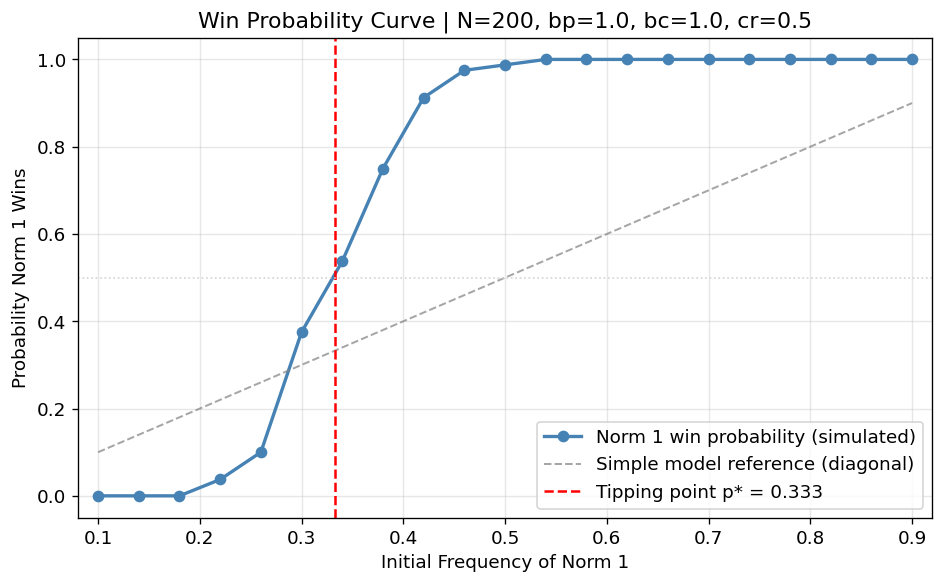

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(init_values, win_probs, 'o-', color='steelblue', linewidth=2, markersize=6,
        label='Norm 1 win probability (simulated)')

# Reference: symmetric diagonal (as in simple model)
ax.plot([0.1, 0.9], [0.1, 0.9], '--', color='gray', linewidth=1.2,
        alpha=0.7, label='Simple model reference (diagonal)')

# Mark the tipping point
ax.axvline(pstar, color='red', linestyle='--', linewidth=1.5,
           label=f'Tipping point p* = {pstar:.3f}')
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)

ax.set_xlabel('Initial Frequency of Norm 1')
ax.set_ylabel('Probability Norm 1 Wins')
ax.set_title(f'Win Probability Curve | N={N}, bp={norm1_prosocial_benefit}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}')
ax.set_xlim(0.08, 0.92)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 4: What Moves p*? — Rarity Cost vs. Coordination Benefit

Since $p^* = c_r / (c_r + b_c)$, we can manipulate $p^*$ by changing either parameter:

- **Higher rarity cost** ($c_r$) → $p^*$ moves right → Norm 1 needs an even bigger head start to spread
- **Higher coordination benefit** ($b_c$) → $p^*$ moves left → Norm 1 can spread even from a minority position

Let's visualize $p^*$ as a function of both parameters.

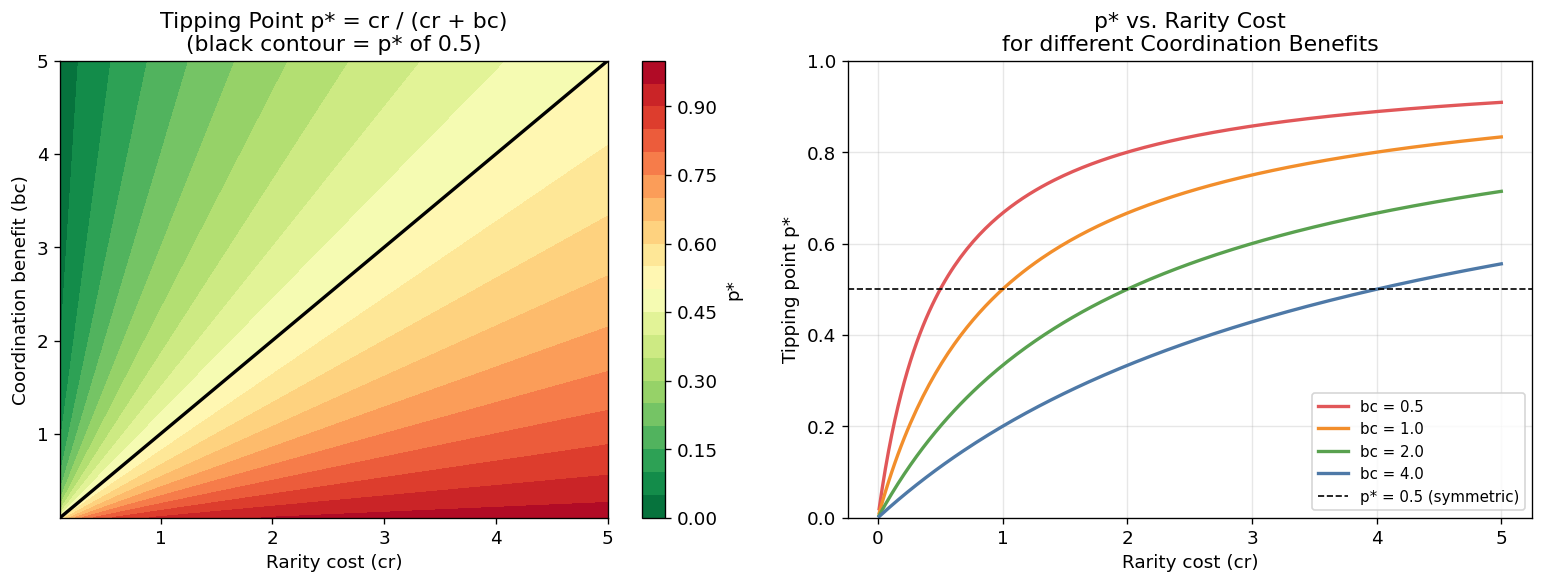

Interpretation:
  Green region (left plot): p* < 0.5 → Norm 1 can spread from a minority
  Red region   (left plot): p* > 0.5 → Norm 1 needs a majority head start
  High bc (blue line, right plot): p* stays low even with high rarity costs


In [9]:
# ── Global parameters for the heatmap ─────────────────────────────────────────
cr_values = np.linspace(0.1, 5.0, 100)   # rarity cost range
bc_values = np.linspace(0.1, 5.0, 100)   # coordination benefit range
# ───────────────────────────────────────────────────────────────────────────────

# Build a 2D grid of p* values
CR, BC = np.meshgrid(cr_values, bc_values)
PSTAR  = CR / (CR + BC)  # the analytical formula, vectorized

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: heatmap of p*
ax = axes[0]
im = ax.contourf(cr_values, bc_values, PSTAR, levels=20, cmap='RdYlGn_r')
ax.contour(cr_values, bc_values, PSTAR, levels=[0.5], colors='black', linewidths=2)
plt.colorbar(im, ax=ax, label='p*')
ax.set_xlabel('Rarity cost (cr)')
ax.set_ylabel('Coordination benefit (bc)')
ax.set_title('Tipping Point p* = cr / (cr + bc)\n(black contour = p* of 0.5)')

# Right: p* as a function of rarity cost for different bc values
ax = axes[1]
bc_examples = [0.5, 1.0, 2.0, 4.0]
colors_bc   = ['#e15759', '#f28e2b', '#59a14f', '#4e79a7']
cr_range    = np.linspace(0.01, 5, 200)

for bc_val, color in zip(bc_examples, colors_bc):
    pstar_line = cr_range / (cr_range + bc_val)  # local
    ax.plot(cr_range, pstar_line, color=color, linewidth=2, label=f'bc = {bc_val}')

ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='p* = 0.5 (symmetric)')
ax.set_xlabel('Rarity cost (cr)')
ax.set_ylabel('Tipping point p*')
ax.set_title('p* vs. Rarity Cost\nfor different Coordination Benefits')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Green region (left plot): p* < 0.5 → Norm 1 can spread from a minority")
print("  Red region   (left plot): p* > 0.5 → Norm 1 needs a majority head start")
print("  High bc (blue line, right plot): p* stays low even with high rarity costs")

---
## 🔬 Experiment 5: Does the Prosocial Benefit (bp) Matter?

The theory says $b_p$ cancels out of $p^*$. Let's verify this computationally:
run the win-probability curve for different values of $b_p$ and confirm the curves all cross 0.5 at the same $p^*$.

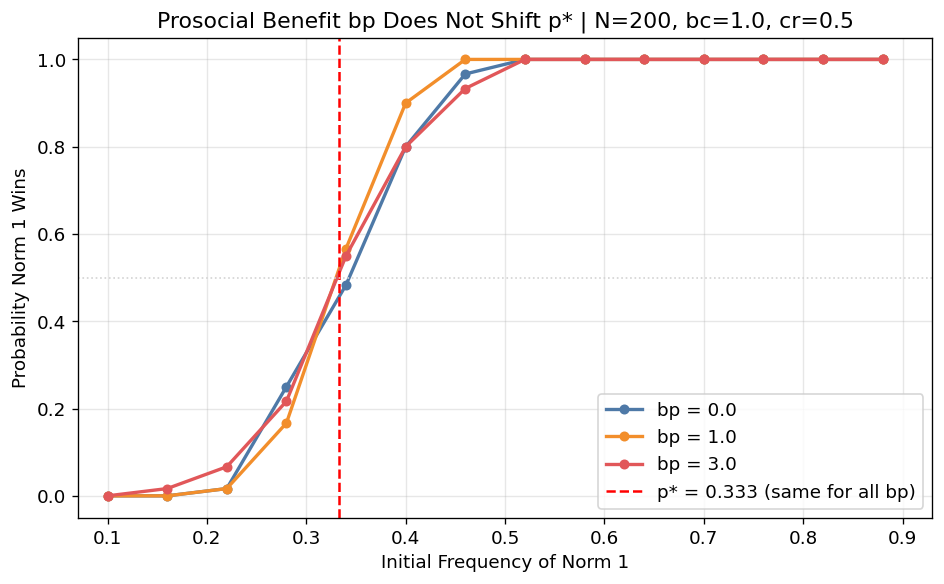

p* = 0.333 regardless of bp value.
All three win-probability curves should cross 0.5 at the same initial frequency.


In [10]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                   = 200
norm1_coord_benefit = 1.0
norm1_rarity_cost   = 0.5
max_ticks           = 4000
n_reps              = 60

# Different values of the prosocial benefit to compare
bp_values = [0.0, 1.0, 3.0]
colors    = ['#4e79a7', '#f28e2b', '#e15759']

# Use a coarser init grid for speed
init_values = np.arange(0.10, 0.91, 0.06)
# ───────────────────────────────────────────────────────────────────────────────

pstar = p_star(norm1_rarity_cost, norm1_coord_benefit)

fig, ax = plt.subplots(figsize=(8, 5))

for bp, color in zip(bp_values, colors):
    win_probs_bp = []  # local

    for init_val in init_values:
        wins = 0
        for _ in range(n_reps):
            h = run(N, init_val, bp, norm1_coord_benefit, norm1_rarity_cost, max_ticks)
            if h[-1] == 1.0:
                wins += 1
        win_probs_bp.append(wins / n_reps)

    ax.plot(init_values, win_probs_bp, 'o-', color=color,
            linewidth=2, markersize=5, label=f'bp = {bp}')

ax.axvline(pstar, color='red', linestyle='--', linewidth=1.5,
           label=f'p* = {pstar:.3f} (same for all bp)')
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)

ax.set_xlabel('Initial Frequency of Norm 1')
ax.set_ylabel('Probability Norm 1 Wins')
ax.set_title(f'Prosocial Benefit bp Does Not Shift p* | N={N}, bc={norm1_coord_benefit}, cr={norm1_rarity_cost}')
ax.set_xlim(0.07, 0.93)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"p* = {pstar:.3f} regardless of bp value.")
print("All three win-probability curves should cross 0.5 at the same initial frequency.")

---
## 🔬 Experiment 6: High Rarity Cost — When Norm 1 Can't Spread

When rarity cost is very high relative to coordination benefit, $p^*$ is pushed above 0.5. This means **even a majority of Norm 1 holders can't guarantee Norm 1 spreads** — the population needs to be overwhelmingly Norm 1 before it takes over.

This models situations like minority languages or unpopular technologies: even if they're better, they can't spread because the cost of being in the minority is too high.

With high rarity cost: p* = 0.750
  → Norm 1 must exceed 75% of the population to be favored.


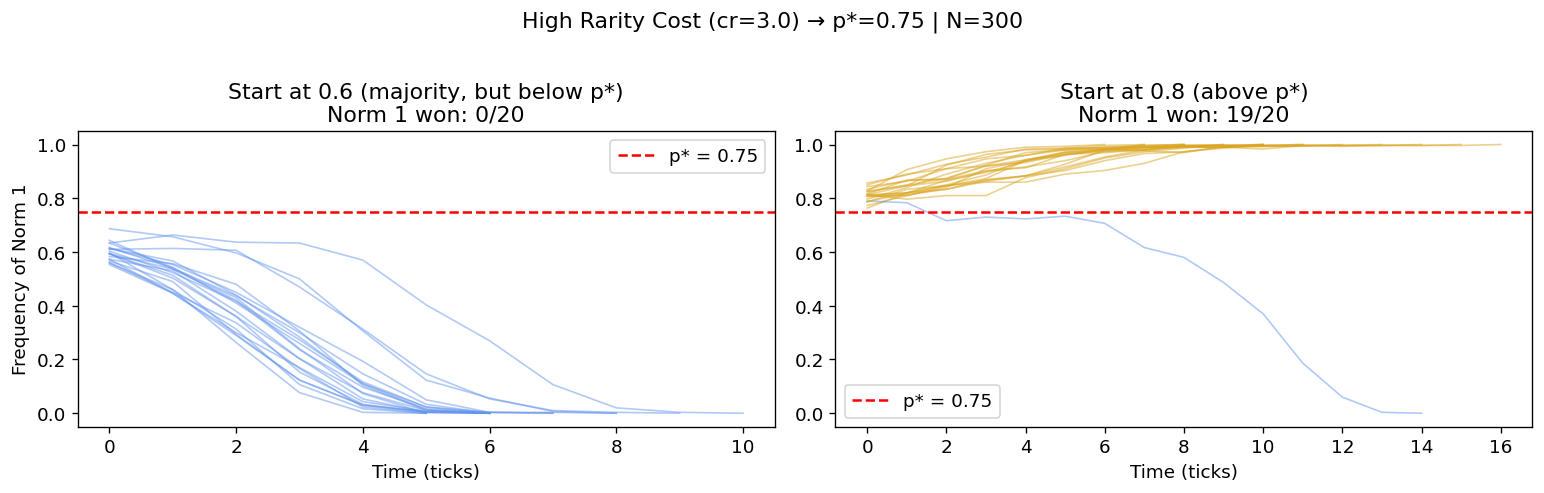

In [11]:
# ── Global parameters ──────────────────────────────────────────────────────────
N                       = 300
norm1_prosocial_benefit = 1.0
norm1_coord_benefit     = 1.0
norm1_rarity_cost       = 3.0   # high! makes p* = 3/(3+1) = 0.75
max_ticks               = 4000
n_runs                  = 20
# ───────────────────────────────────────────────────────────────────────────────

pstar_high = p_star(norm1_rarity_cost, norm1_coord_benefit)
print(f"With high rarity cost: p* = {pstar_high:.3f}")
print(f"  → Norm 1 must exceed {pstar_high*100:.0f}% of the population to be favored.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: start at 60% — above 50% but below p*
ax = axes[0]
init_below_pstar = 0.60  # majority, but below p*
wins = 0
for _ in range(n_runs):
    h = run(N, init_below_pstar, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost, max_ticks)
    won = h[-1] == 1.0
    if won: wins += 1
    ax.plot(h, color='goldenrod' if won else 'cornflowerblue', alpha=0.5, linewidth=1)

ax.axhline(pstar_high, color='red', linestyle='--', linewidth=1.5, label=f'p* = {pstar_high:.2f}')
ax.set_title(f'Start at {init_below_pstar} (majority, but below p*)\nNorm 1 won: {wins}/{n_runs}')
ax.set_xlabel('Time (ticks)')
ax.set_ylabel('Frequency of Norm 1')
ax.set_ylim(-0.05, 1.05)
ax.legend()

# Right: start at 80% — above p*
ax = axes[1]
init_above_pstar = 0.80
wins = 0
for _ in range(n_runs):
    h = run(N, init_above_pstar, norm1_prosocial_benefit, norm1_coord_benefit, norm1_rarity_cost, max_ticks)
    won = h[-1] == 1.0
    if won: wins += 1
    ax.plot(h, color='goldenrod' if won else 'cornflowerblue', alpha=0.5, linewidth=1)

ax.axhline(pstar_high, color='red', linestyle='--', linewidth=1.5, label=f'p* = {pstar_high:.2f}')
ax.set_title(f'Start at {init_above_pstar} (above p*)\nNorm 1 won: {wins}/{n_runs}')
ax.set_xlabel('Time (ticks)')
ax.set_ylim(-0.05, 1.05)
ax.legend()

fig.suptitle(f'High Rarity Cost (cr={norm1_rarity_cost}) → p*={pstar_high:.2f} | N={N}', y=1.02)
plt.tight_layout()
plt.show()

---

## 📝 Conceptual Summary

| Concept | What It Means In This Model |
|---|---|
| **Asymmetric coordination** | Norm 1 is better collectively but harder to adopt when rare |
| **Prosocial benefit (bp)** | Norm 1 agents are helpful even to Norm 2 agents — but this doesn't shift p* |
| **Coordination benefit (bc)** | Extra payoff when two Norm 1 agents meet — this lowers p* |
| **Rarity cost (cr)** | Norm 1 agents pay a cost when paired with Norm 2 agents — this raises p* |
| **Tipping point p*** | $c_r / (c_r + b_c)$ — the frequency Norm 1 must exceed to spread |
| **Unstable equilibrium** | p* is the exact balance point — the system won't stay there |
| **Path dependence** | History (especially the starting condition) determines which norm prevails |
| **Norm lock-in** | Once below p*, Norm 1 can't recover even if it's collectively better |
| **Real-world implication** | Better norms can fail to spread if their rarity cost is too high |

---

## 🔗 Key Difference from the Simple Model

| Feature | Simple Model | Asymmetric Model |
|---|---|---|
| Norm quality | Equal — neither is intrinsically better | Unequal — Norm 1 is prosocially superior |
| Tipping point | Always at p* = 0.5 | At p* = cr/(cr+bc), can be anywhere in (0,1) |
| Who can win? | Whoever starts higher | Whoever crosses p*, regardless of which is "better" |
| Imitation rule | Only consider different-norm agents | Consider any agent (same or different norm) |
| Main lesson | Coordination is history-dependent | Even superior norms can be locked out by rarity costs |